# Day 16: Shot and goal EDA in football (spatial distributions)

**Phase 2: EDA & Feature Engineering**

## Objective
Shot and goal EDA in football (spatial distributions)

## Task 
* Load and explore the processed data in parquet format (`fact_events.parquet`).
* **Data Engineering (Troubleshooting):** Identify and fix a column assignment bug in the Day 10 ETL that caused all spatial coordinates to be empty (NaN).
* Filter the events dataset to isolate only the shots (`type == 'Shot'`).
* Create basic Scatter Plots to understand the StatsBomb coordinate system (120x80).
* Use the specialized `mplsoccer` library to plot the shots on a real football pitch visualization.
* Add dimensionality to the spatial map by scaling the point size based on the quality metric: Expected Goals (`xG`).
* Analyze the statistical distribution of xG using a histogram (KDE plot) to observe the scarcity of clear chances and the impact of penalties on the distribution.

**Deliverable:** `day016_shot_analysis_eda.ipynb` notebook completed with spatial and statistical visualizations of shots, and a critical bugfix in the Phase 1 pipeline.


**Deliverable:** Notebook day016_shot_analysis_eda.ipynb with 5+ publishable visualizations.

---

### Instructions:
*Treat this as your course workbook. Write your code, notes, or execution steps below.*

Remember: 
- Document your decisions.
- Use clear variable names.
- If today's task involves creating a script in `src/`, a dashboard in `apps/`, or documentation in `docs/`, you can use this notebook to test your logic or simply write your reflections and proofs of execution (e.g. running terminal commands with `!`).



In [1]:
# 1. Import main libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) Set a clean visual style for our plots
sns.set_theme(style="whitegrid")

# 2. Define the file path (relative path to go up two directories)
file_path = '../../data/processed/football/fact_events.parquet'

# 3. Read the parquet file into a DataFrame
df_events = pd.read_parquet(file_path)

# 4. Display the first 5 rows to explore the dataset
df_events.head()


,event_id,match_id,player_id,team_id,type,minute,second,pass_length,pass_angle,shot_statsbomb_xg,location_x,location_y
0,093f898d-33b1-4425-b591-37dd9c9bf70b,3857256,NaN,786,Starting XI,0,0,NaN,NaN,NaN,NaN,NaN
1,79a9efbb-b5e5-45b0-983d-8729bcc4a0e1,3857256,NaN,773,Starting XI,0,0,NaN,NaN,NaN,NaN,NaN
2,c4cdfc71-b9f4-4751-a714-e816c1419457,3857256,NaN,773,Half Start,0,0,NaN,NaN,NaN,NaN,NaN
3,51f295b8-da96-428e-ab47-90f380f8cf53,3857256,NaN,786,Half Start,0,0,NaN,NaN,NaN,NaN,NaN
4,749a27ed-92e8-4723-9ac5-dcd074535537,3857256,NaN,786,Half Start,45,0,NaN,NaN,NaN,NaN,NaN


In [4]:
#Filter only shots
df_shots = df_events[df_events['type']== 'Shot']
df_shots.head()

,event_id,match_id,player_id,team_id,type,minute,second,pass_length,pass_angle,shot_statsbomb_xg,location_x,location_y
2674,61d52e72-a8ff-49c4-be02-057b1ea0fb15,3857256,3500.0,773,Shot,0,18,NaN,NaN,0.036566,96.0,38.8
2675,aa77495b-0e7b-44f0-a2eb-11605085943a,3857256,5545.0,773,Shot,0,22,NaN,NaN,0.353289,113.1,40.7
2676,51026369-a4ad-4a71-b14a-6e7f8b764772,3857256,3500.0,773,Shot,0,23,NaN,NaN,0.069527,103.8,41.9
2677,6ac240f5-8b84-4c06-8153-b56109c8c5e6,3857256,5603.0,786,Shot,4,35,NaN,NaN,0.081609,112.2,36.8
2678,00e599c0-5234-4b6a-9b91-d6f789a311b0,3857256,6318.0,786,Shot,10,5,NaN,NaN,0.030002,97.8,51.5


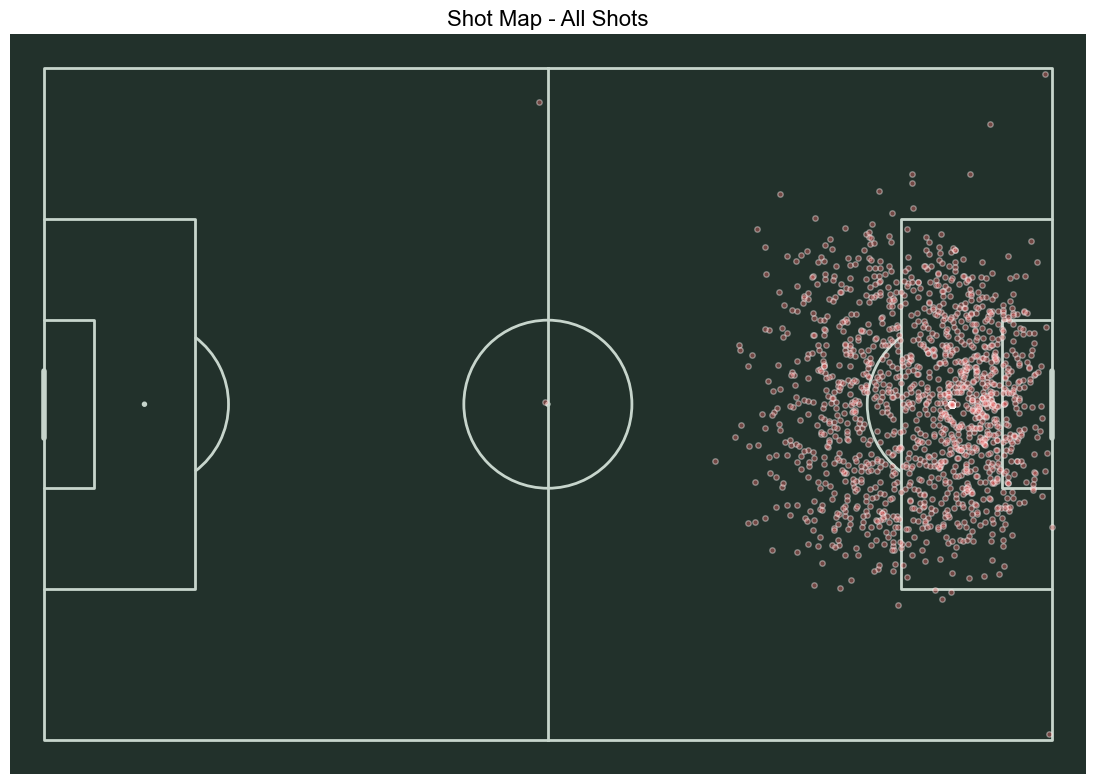

In [9]:
# 1. Import the Pitch class from mplsoccer
from mplsoccer import Pitch

# 2. Create the pitch object. 
# We specify pitch_type='statsbomb' because our data is 120x80
# We use some hex colors for a cool dark theme
pitch = Pitch(
    pitch_type='statsbomb', 
    pitch_color='#22312b', 
    line_color='#c7d5cc'
)

# 3. Draw the pitch. This gives us a Figure (fig) and an Axis (ax)
fig, ax = pitch.draw(figsize=(12, 8))

# 4. Plot the shots on top of the pitch!
pitch.scatter(
    df_shots['location_x'], 
    df_shots['location_y'], 
    ax=ax, 
    alpha=0.4,       # Transparency
    s=15,            # Size
    color='#ea6969', # A nice red color for the shots
    edgecolors='white' # White border around each dot
)

plt.title('Shot Map - All Shots', color='black', fontsize=16)

plt.show()



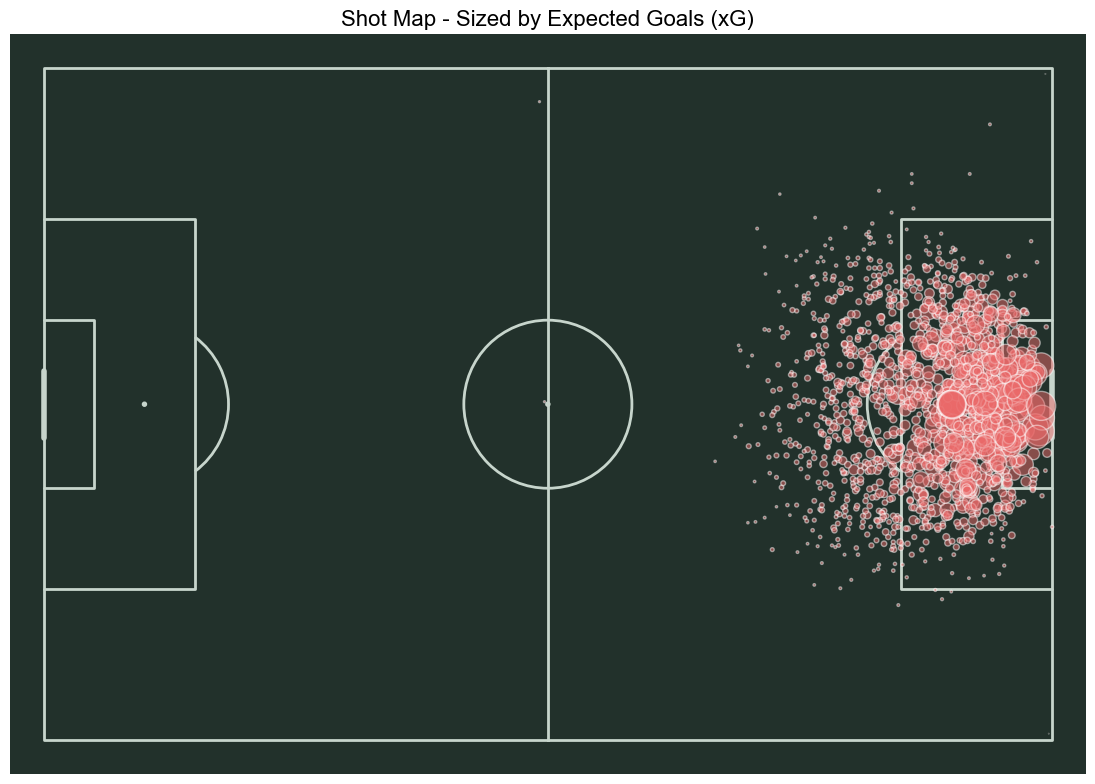

In [ ]:
# 1. Create the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(12, 8))

# 2. Plot the shots, BUT size them by xG!
# We multiply xG by 500 just to make the dots big enough to see
pitch.scatter(
    df_shots['location_x'], 
    df_shots['location_y'], 
    s=df_shots['shot_statsbomb_xg'] * 500,
    ax=ax, 
    alpha=0.5, 
    color='#ea6969',
    edgecolors='white'
)

# 3. Add title
plt.title('Shot Map - Sized by Expected Goals (xG)', color='black', fontsize=16)

plt.show()


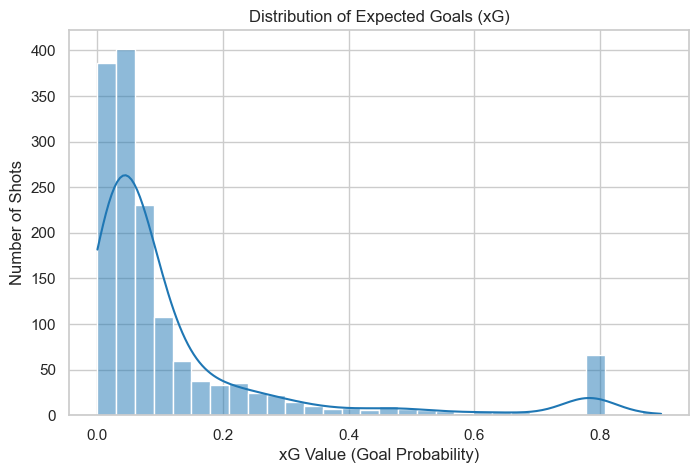

In [12]:
plt.figure(figsize=(8, 5))

# Create the histogram
sns.histplot(data=df_shots, x='shot_statsbomb_xg', bins=30, color='#1f77b4', kde=True)

# Add titles and labels in English
plt.title('Distribution of Expected Goals (xG)')
plt.xlabel('xG Value (Goal Probability)')
plt.ylabel('Number of Shots')

plt.show()



## Day 16 Conclusions

* EDA as a Bug Detector: During the initial Exploratory Data Analysis, we discovered a critical bug in our data pipeline (Day 10) that prevented the correct extraction of the spatial coordinates `location_x` and `location_y`. Going back to fix the root cause was a fundamental Data Engineering step.
* Spatial Distribution and the "Golden Zone": By visualizing the shots on a real pitch (using `mplsoccer`), we visually confirmed that the vast majority of attempts are concentrated in the center and near the six-yard box/penalty spot.
* xG (Expected Goals) as a Quality Metric: We moved from measuring just "volume" to measuring "quality" or "decision making" by scaling the size of the points based on their goal probability (`shot_statsbomb_xg`). We confirmed that long-distance shots are, statistically, poor decisions.
* Football is a Game of Scarcity: The xG histogram showed a brutal right-skewed distribution. The vast majority of shots in a match have less than a 10% chance of being a goal. The anomalous spikes at high probabilities (~0.76 - 0.80) almost exclusively correspond to a specific set piece: penalties.
